# Biodegradation % Predictor

**Author:** Lab of Farm Structures
**Date:** 2026-03

## Import libraries

In [1]:
import pandas as pd
import kennard_stone as ks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import shap
from prince import FAMD
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
import seaborn as sns
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar

## Load data

In [57]:
model_biodeg = 'biodegradation_loss_data_LM_new'

df_biodeg = pd.read_csv(f'{model_biodeg}.csv')
df_biodeg.tail()

,biodegradation_time_days,biodegradation_percentage,study_id,instance,phb_initial_mol,phv_initial_mol,biodegradation_condition,degradation_mechanism,t_biodeg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,sample_shape_morphology,pha_degrading_microbes,additives
1359,100.0,82.0,24,4,98,2,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,yes
1360,105.0,86.0,24,4,98,2,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,yes
1361,117.0,91.0,24,4,98,2,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,yes
1362,132.0,96.0,24,4,98,2,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,yes
1363,141.0,99.0,24,4,98,2,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,films,diverse_environmental,yes


## Exclude randomly one instance from multi-instance studies

In [58]:
np.random.seed(42)

# Count rows per Study_id and Instance
instance_row_counts = (
    df_biodeg.groupby(['study_id', 'instance'])
    .size()  
)

# Keep only instances with at least 5 rows
valid_instances = instance_row_counts[instance_row_counts >= 5]

# Study_ids with more than one instance
instance_counts = valid_instances.groupby('study_id').size()

# Keep only Study_ids with more than 3 valid instance
multi_study_ids = instance_counts[instance_counts > 3].index

# Randomly select one instance per such Study_id
excluded_instances = (
    df_biodeg[df_biodeg['study_id'].isin(multi_study_ids)]
    .groupby('study_id')['instance']
    .apply(lambda x: np.random.choice(x.unique()))
    .reset_index(name='Excluded_Instance')
)

# reduce the amount of val set
excluded_instances = excluded_instances[
    ~excluded_instances['study_id'].isin([1])
]

# Merge back to create a row-aligned mask
df_with_exclusion = df_biodeg.merge(
    excluded_instances,
    on='study_id',
    how='left'
)

# Rows to exclude: those matching the randomly selected instance
exclude_mask = df_with_exclusion['instance'] == df_with_exclusion['Excluded_Instance']

# Split the dataframes
df_val = df_with_exclusion[exclude_mask].drop(columns='Excluded_Instance')
df_biodeg = df_with_exclusion[~exclude_mask].drop(columns='Excluded_Instance')

print(df_val[['study_id', 'instance']].drop_duplicates())

      study_id  instance
597          6         4
865         16         1
1076        20         3
1152        22         3
1264        23         4
1275        24         1


In [59]:
print('train/test set size:', df_biodeg.shape, '\n Val set size',df_val.shape)

train/test set size: (1226, 19) 
 Val set size (138, 19)


## Select Features and Target

In [60]:
df_biodeg.columns

Index(['biodegradation_time_days', 'biodegradation_percentage', 'study_id',
       'instance', 'phb_initial_mol', 'phv_initial_mol',
       'biodegradation_condition', 'degradation_mechanism', 't_biodeg',
       'degradation_environment', 'additive_type_1', 'additive1_percentage_wt',
       'additive_type_2', 'additive2_percentage_wt', 'additive_type_3',
       'additive3_percentage_wt', 'sample_shape_morphology',
       'pha_degrading_microbes', 'additives'],
      dtype='object')

In [61]:
features = [
    'phb_initial_mol',
    'phv_initial_mol',
    'biodegradation_time_days',
    'biodegradation_condition',
    'degradation_mechanism',
    't_biodeg',
    'degradation_environment',
    'additive_type_1',
    'additive1_percentage_wt',
    'additive_type_2',
    'additive2_percentage_wt',
    'additive_type_3',
    'additive3_percentage_wt',
    'pha_degrading_microbes',
    'sample_shape_morphology',
    'additives'
]

target = 'biodegradation_percentage'

measure_unit = '%'

In [62]:
# Create DataFrame
df_new = df_biodeg[features + [target]]

# Drop rows with N/A value
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.tail()

,phb_initial_mol,phv_initial_mol,biodegradation_time_days,biodegradation_condition,degradation_mechanism,t_biodeg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,pha_degrading_microbes,sample_shape_morphology,additives,biodegradation_percentage
1359,98,2,100.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,yes,82.0
1360,98,2,105.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,yes,86.0
1361,98,2,117.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,yes,91.0
1362,98,2,132.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,yes,96.0
1363,98,2,141.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,plasticizer,5.0,no_additive,0.0,no_additive,0.0,diverse_environmental,films,yes,99.0


In [63]:
df_final.shape

(1226, 17)

In [64]:
# numerical columns
numerical_cols_lst = df_final.select_dtypes(include=[np.number]).columns.tolist()
# categorical columns 
categorical_cols_lst = df_final.select_dtypes(include=['object', 'category']).columns.tolist()

## Plot feature distribution

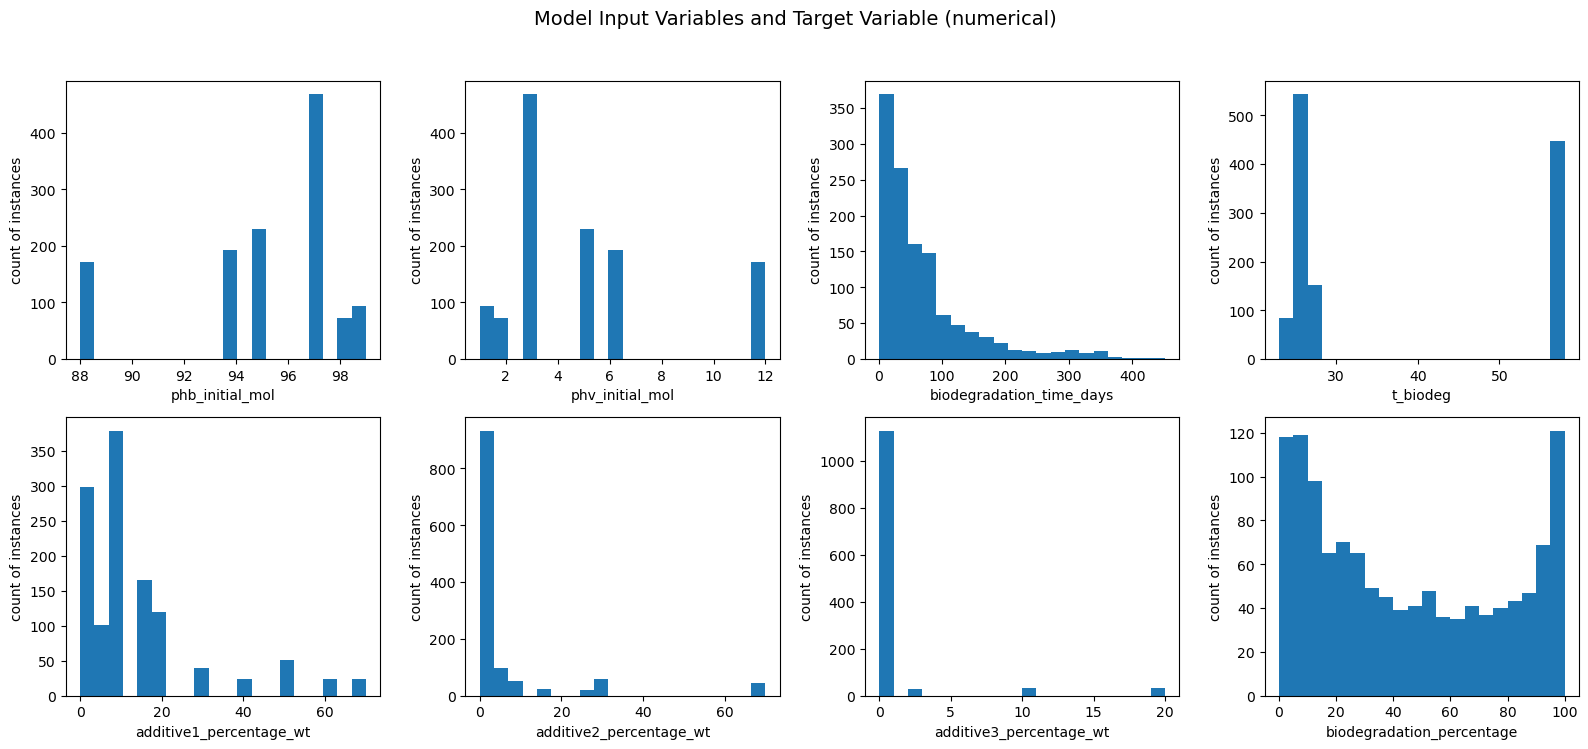

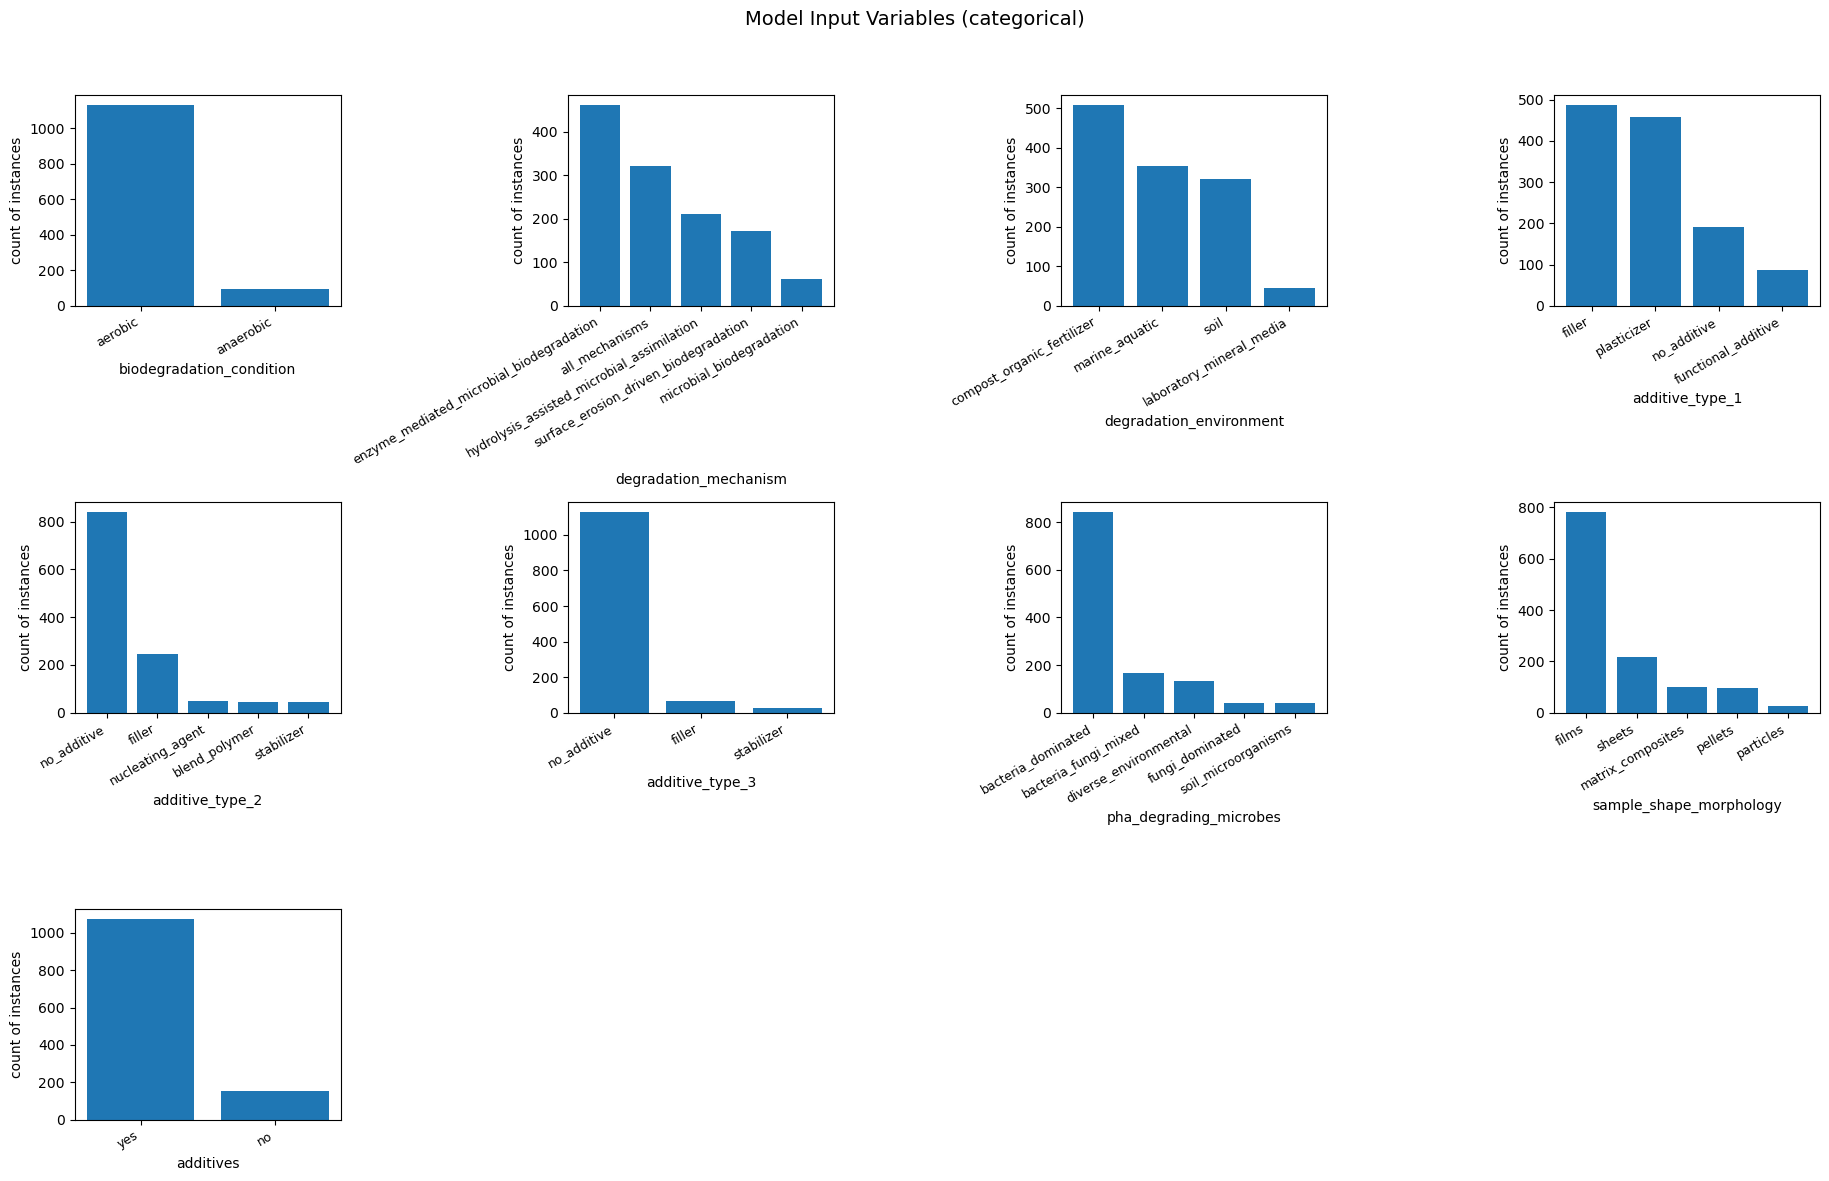

In [65]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Correlation matrix of numerical features

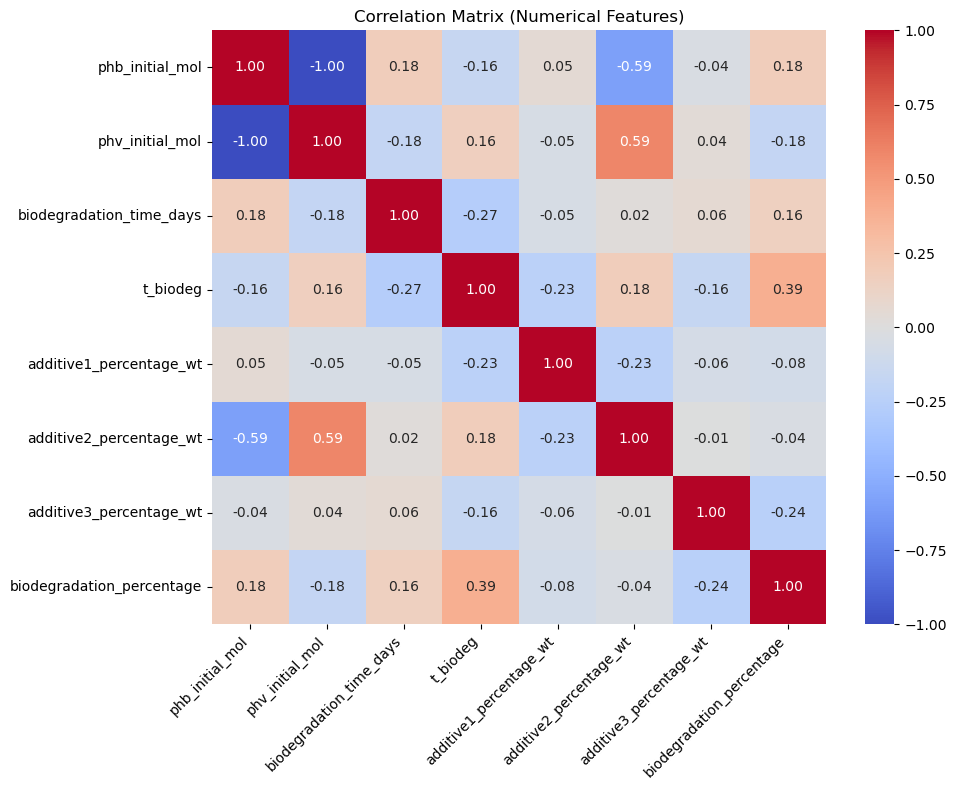

In [66]:
numerical_df = df_final[numerical_cols_lst]

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
df_final.drop(columns=['phv_initial_mol'], inplace=True)

## Train - test splitting

In [68]:
# Separate features and target
X = df_final.drop(columns=[target]) 
y = df_final[target]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Train set size:', X_train.shape, '\n Test set size',X_test.shape)

Train set size: (980, 15) 
 Test set size (246, 15)


## FAMD for outlier detection - only on the Train set (if applied)

In [70]:
# Fit FAMD with a reasonably high number of components
famd = FAMD(n_components=30, n_iter=10, random_state=42).fit(X_train)

eigenvalues = famd.eigenvalues_
explained_inertia = eigenvalues / eigenvalues.sum()
cumulative_inertia = np.cumsum(explained_inertia)

famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,21.957,13.72%,13.72%
1,20.332,12.71%,26.43%
2,15.731,9.83%,36.26%
3,15.039,9.40%,45.66%
4,12.178,7.61%,53.27%
5,10.463,6.54%,59.81%
6,10.027,6.27%,66.08%
7,8.508,5.32%,71.40%
8,7.825,4.89%,76.29%


In [71]:
# Initial FAMD for outlier detection
n_components_initial = 28
famd2 = FAMD(n_components=n_components_initial, random_state=42)
X_train_famd = famd2.fit_transform(X_train)

X_train_famd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 306 to 1236
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       980 non-null    float64
 1   1       980 non-null    float64
 2   2       980 non-null    float64
 3   3       980 non-null    float64
 4   4       980 non-null    float64
 5   5       980 non-null    float64
 6   6       980 non-null    float64
 7   7       980 non-null    float64
 8   8       980 non-null    float64
 9   9       980 non-null    float64
 10  10      980 non-null    float64
 11  11      980 non-null    float64
 12  12      980 non-null    float64
 13  13      980 non-null    float64
 14  14      980 non-null    float64
 15  15      980 non-null    float64
 16  16      980 non-null    float64
 17  17      980 non-null    float64
 18  18      980 non-null    float64
 19  19      980 non-null    float64
 20  20      980 non-null    float64
 21  21      980 non-null    float64
 22  22  

In [72]:
X_train_famd_df = X_train_famd.copy()
X_train_famd_df.columns = [f'Comp{i+1}' for i in range(X_train_famd_df.shape[1])]

X_train_famd_df.tail()

,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6,Comp7,Comp8,Comp9,Comp10,...,Comp19,Comp20,Comp21,Comp22,Comp23,Comp24,Comp25,Comp26,Comp27,Comp28
1132,2.696514,-1.832929,-0.372519,-6.332573,3.012340,-2.320841,-0.226133,2.686457,0.785199,-3.984074,...,0.080574,-0.013161,0.350395,0.158001,-0.573712,-1.681574,0.586364,-0.719227,0.986283,0.003136
1205,5.347862,-1.627457,-2.086689,-6.747482,3.806506,-2.742645,3.793917,1.938945,1.214387,-4.433473,...,0.209842,0.172917,-1.204479,0.507954,0.738289,-0.695708,-0.169516,0.784481,-0.674016,0.005226
1240,-5.302401,1.260696,-5.782790,-2.619406,0.627390,0.396290,3.671835,-3.823510,0.532882,2.103869,...,-0.151087,-0.959477,-0.234463,-0.407731,-0.823694,0.359241,-0.153849,-0.598674,-0.987109,-0.000986
933,0.910535,1.508605,-1.258354,3.212906,-1.103357,-0.023048,-1.552612,1.191694,-0.517896,-0.978998,...,-0.639821,-1.230142,-0.342314,-0.295400,-0.546476,-0.329006,0.183641,1.226470,-0.108525,0.004157
1236,-5.301592,1.274415,-5.801858,-2.603412,0.622524,0.413685,3.646855,-3.813631,0.551165,2.131437,...,-0.134726,-0.919240,-0.234873,-0.374351,-0.750469,0.151065,-0.116611,-0.612262,-0.970024,-0.000841


## Outlier detection with IQR

**Test = 1:** No exclusion
**Test = 2:** +-10 IQR   **Test = 3:** +-7 IQR  

In [73]:
test = 1

# Detect outliers using IQR
def detect_iqr_outliers(df,alpha):
    outlier_indices = set()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - alpha * IQR
        upper_bound = Q3 + alpha * IQR
        outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers_col)
    return list(outlier_indices)

# Drop outliers
if test == 2:
    alpha = 10
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±2")

elif test == 3:
    alpha = 7
    outlier_idx_train = detect_iqr_outliers(X_train_famd_df, alpha)
    X_train_clean = X_train.drop(index=outlier_idx_train)
    y_train_clean = y_train.drop(index=outlier_idx_train)
    print("IQR outlier detection APPLIED with ±",alpha)

else:
    df_clean = df_final.copy()
    X_train_clean = X_train
    y_train_clean = y_train
    print("IQR outlier detection SKIPPED")

print(f"Original data shape: {X_train.shape}")
print(f"Cleaned data shape: {X_train_clean.shape}")

IQR outlier detection SKIPPED
Original data shape: (980, 15)
Cleaned data shape: (980, 15)


In [74]:
X_train_clean.tail()

,phb_initial_mol,biodegradation_time_days,biodegradation_condition,degradation_mechanism,t_biodeg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,additive_type_3,additive3_percentage_wt,pha_degrading_microbes,sample_shape_morphology,additives
1132,95,58.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,filler,15.0,no_additive,0.0,no_additive,0.0,bacteria_dominated,matrix_composites,yes
1205,95,101.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,no_additive,0.0,filler,25.0,no_additive,0.0,bacteria_dominated,matrix_composites,yes
1240,97,120.0,aerobic,all_mechanisms,28.0,soil,no_additive,0.0,no_additive,0.0,no_additive,0.0,bacteria_fungi_mixed,films,no
933,97,55.0,aerobic,enzyme_mediated_microbial_biodegradation,58.0,compost_organic_fertilizer,plasticizer,10.0,no_additive,0.0,no_additive,0.0,bacteria_dominated,films,yes
1236,97,102.0,aerobic,all_mechanisms,28.0,soil,no_additive,0.0,no_additive,0.0,no_additive,0.0,bacteria_fungi_mixed,films,no


## One-hot encoding

In [75]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols_lst])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols_lst])
X_test_ohe = ohe.transform(X_test[categorical_cols_lst])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols_lst)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [76]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols_lst), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols_lst), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (980, 41)
X_test_final shape: (246, 41)


## Feature importance with RF classifier

In [77]:
base_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

base_model.fit(X_train_final, y_train_clean)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
perm = permutation_importance(
    base_model,
    X_train_final,
    y_train_clean,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy" 
)

In [79]:
importance_df = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head()

,feature,importance
1,biodegradation_time_days,0.816429
3,additive1_percentage_wt,0.090408
30,pha_degrading_microbes_bacteria_fungi_mixed,0.044388
4,additive2_percentage_wt,0.037245
0,phb_initial_mol,0.020714


In [80]:
selected_features = (
    importance_df
    .query("importance > 0")
    ["feature"]
    .tolist()
)

In [81]:
X_train_final = X_train_final[selected_features]
X_test_final = X_test_final[selected_features]

## RF and XGBoost regression

In [82]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_xgb = xgb.predict(X_train_final)
y_test_pred_xgb = xgb.predict(X_test_final)


# Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train_clean)

# Predictions
y_train_pred_rf = rf.predict(X_train_final)
y_test_pred_rf = rf.predict(X_test_final)

In [83]:
def compute_metrics(y_true, y_pred):
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

metrics = []

# XGBoost
train_xgb = compute_metrics(y_train_clean, y_train_pred_xgb)
test_xgb = compute_metrics(y_test, y_test_pred_xgb)

metrics.append(['XGBoost', 'Train', train_xgb['R^2'], train_xgb['RMSE'], train_xgb['MAE']])
metrics.append(['XGBoost', 'Test',  test_xgb['R^2'],  test_xgb['RMSE'],  test_xgb['MAE']])

# Random Forest
train_rf = compute_metrics(y_train_clean, y_train_pred_rf)
test_rf = compute_metrics(y_test, y_test_pred_rf)

metrics.append(['Random Forest', 'Train', train_rf['R^2'], train_rf['RMSE'], train_rf['MAE']])
metrics.append(['Random Forest', 'Test',  test_rf['R^2'],  test_rf['RMSE'],  test_rf['MAE']])

In [84]:
metrics_df = pd.DataFrame(
    metrics,
    columns=['Model', 'Dataset', 'R^2', 'RMSE', 'MAE']
)

print(metrics_df)

           Model Dataset       R^2      RMSE       MAE
0        XGBoost   Train  0.980142  4.710617  2.312070
1        XGBoost    Test  0.960375  6.529474  3.902719
2  Random Forest   Train  0.980614  4.654287  2.072749
3  Random Forest    Test  0.956420  6.847559  4.145146


## Grid search - RF

In [85]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search.fit(X_train_final, y_train_clean)

# Extract the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print
print(f"Best parameters found: {best_params}")
print(f"Best R^2 score from Grid Search (CV): {best_score}")

# Use the best estimator
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred_grid = best_rf.predict(X_train_final)
y_test_pred_grid = best_rf.predict(X_test_final)

# Metrics
r2_train_grid = r2_score(y_train_clean, y_train_pred_grid)
r2_test_grid = r2_score(y_test, y_test_pred_grid)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid = cross_val_score(best_rf, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid = np.mean(cv_scores_r2_grid)
std_cv_r2_grid = np.std(cv_scores_r2_grid)

# Print
summary_df = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'Random Forest (Tuned)': [
        r2_train_grid,
        r2_test_grid,
        mean_cv_r2_grid,
        std_cv_r2_grid
    ]
})

print(summary_df)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples

## Plot results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_rf, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_rf, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
# plt.savefig("RF_pair.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

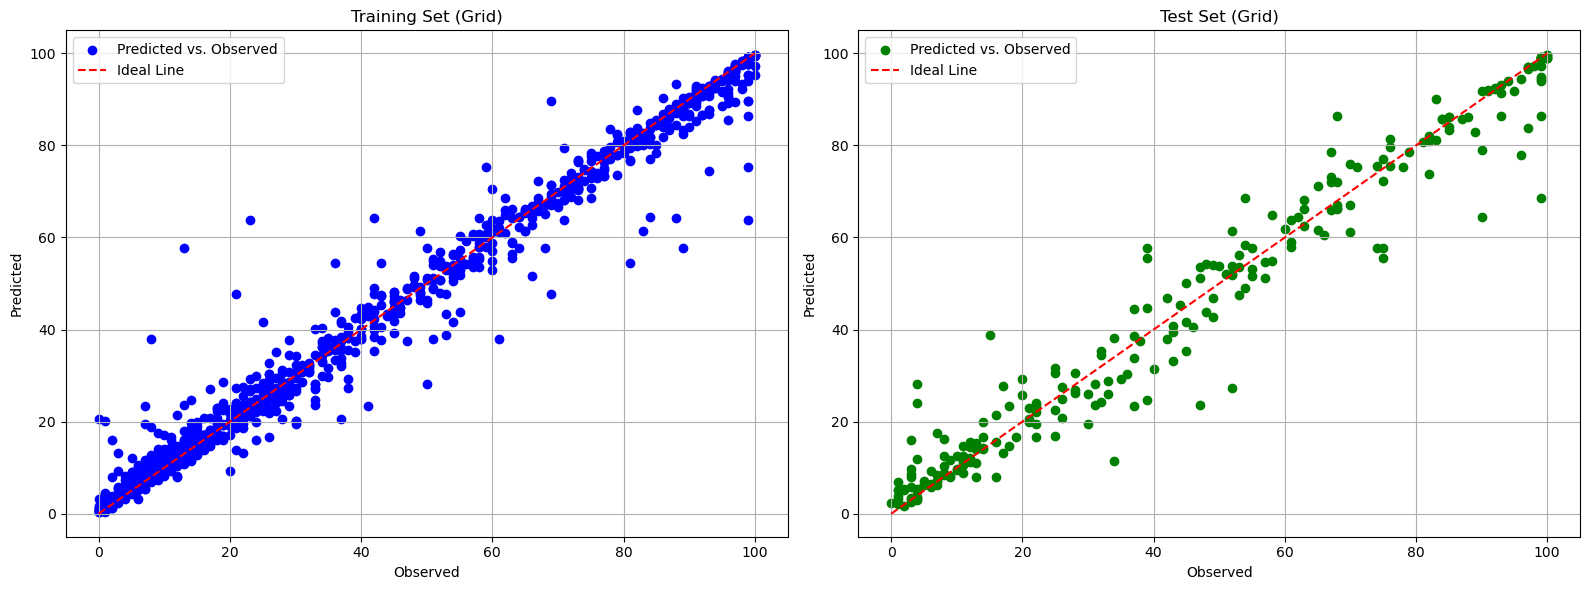

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid, color='blue', label='Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Training Set (Grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test Set (Grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("RF_pair_grid2.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Plot RMSE w.r.t No of trees

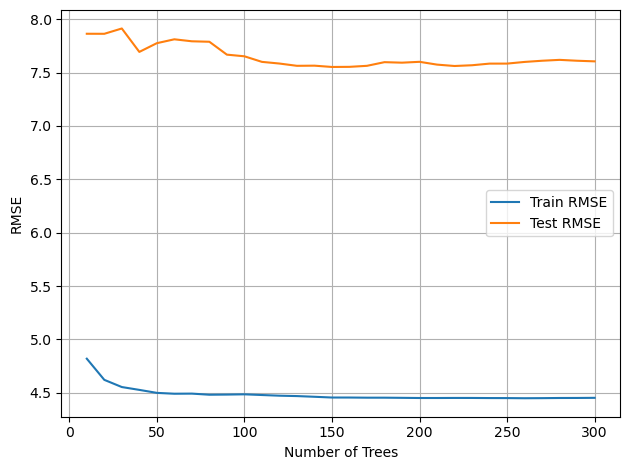

In [41]:
train_rmse = []
test_rmse = []

n_estimators_range = range(10, 301, 10)

for n in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train_clean)

    y_train_pred = rf.predict(X_train_final)
    y_test_pred = rf.predict(X_test_final)

    train_rmse.append(root_mean_squared_error(y_train_clean, y_train_pred))
    test_rmse.append(root_mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(n_estimators_range, train_rmse, label="Train RMSE")
plt.plot(n_estimators_range, test_rmse, label="Test RMSE")
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig("RF_RMSE.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [101]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

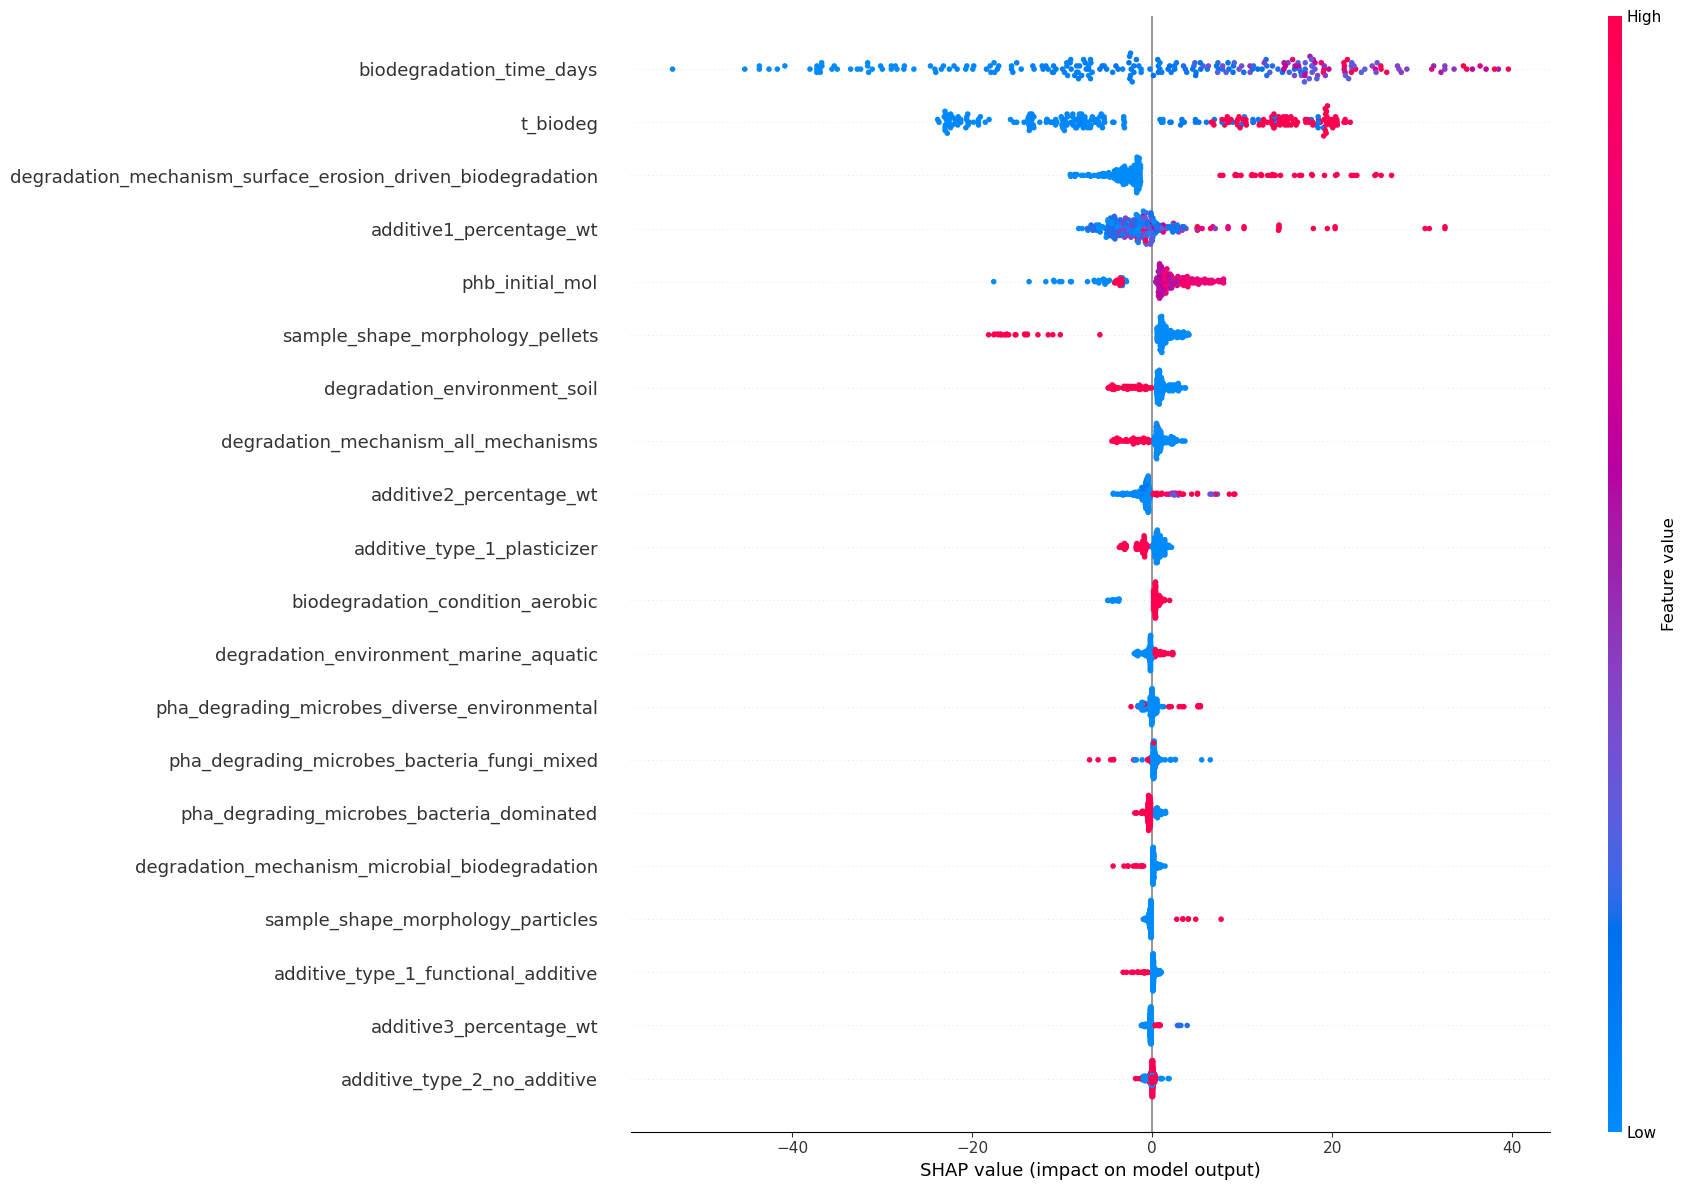

In [102]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("RF_shap2.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Grid search - XGBoost

In [90]:
# Define the parameter grid
param_grid = {
     'n_estimators': [200, 400, 800],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8]
}

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

# Initialize the Grid Search with Random Forest
grid_search2 = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=1, verbose=2)

# Fit
grid_search2.fit(X_train_final, y_train_clean)

# Extract the best parameters
best_params2 = grid_search2.best_params_
best_score2 = grid_search2.best_score_

# Print
print(f"Best parameters found: {best_params2}")
print(f"Best R^2 score from Grid Search (CV): {best_score2}")

# Use the best estimator
best_xgb = grid_search2.best_estimator_

# predictions
y_train_pred_grid2 = best_xgb.predict(X_train_final)
y_test_pred_grid2 = best_xgb.predict(X_test_final)

# Metrics
r2_train_grid2 = r2_score(y_train_clean, y_train_pred_grid2)
r2_test_grid2 = r2_score(y_test, y_test_pred_grid2)

# Cross-Validation R^2 Score with the best model
cv_scores_r2_grid2 = cross_val_score(best_xgb, X_train_final, y_train_clean, cv=cv, scoring='r2')
mean_cv_r2_grid2 = np.mean(cv_scores_r2_grid2)
std_cv_r2_grid2 = np.std(cv_scores_r2_grid2)

# Print the R^2 scores
summary_df2 = pd.DataFrame({
    'Metric': ['Train R^2', 'Test R^2', 'CV Mean R^2', 'CV SD R^2'],
    'XGBoost (Tuned)': [
        r2_train_grid2,
        r2_test_grid2,
        mean_cv_r2_grid2,
        std_cv_r2_grid2
    ]
})

print(summary_df2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END 

## Plot results

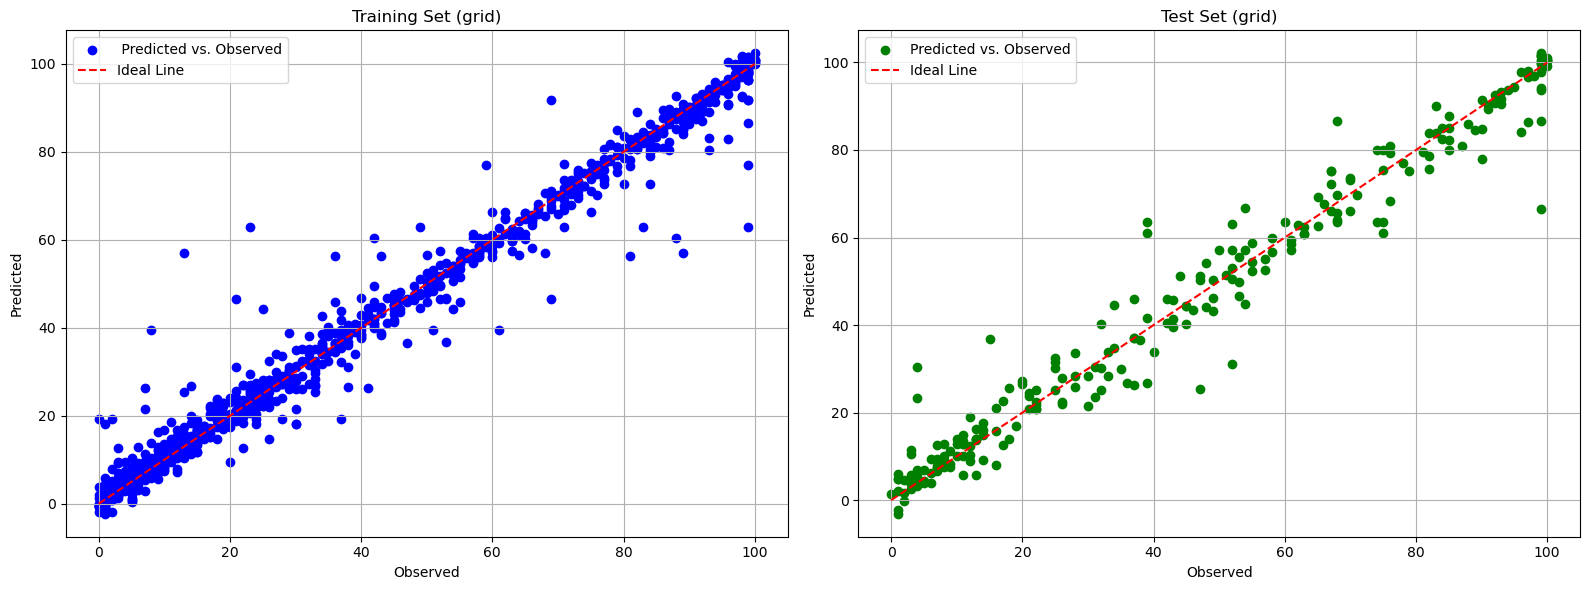

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

# Plot Training Set
axes[0].scatter(y_train_clean, y_train_pred_grid2, color='blue', label=' Predicted vs. Observed')
axes[0].plot([min(y_train_clean), max(y_train_clean)],
             [min(y_train_clean), max(y_train_clean)],
             linestyle='--', color='red', label='Ideal Line')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training Set (grid)')
axes[0].legend()
axes[0].grid(True)

# Plot Test Set
axes[1].scatter(y_test, y_test_pred_grid2, color='green', label='Predicted vs. Observed')
axes[1].plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)],
             linestyle='--', color='red', label='Ideal Line')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test Set (grid)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("XGB_pair_grid2.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Loss plot

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=best_params2['max_depth'],
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["rmse"],
    random_state=42
)

model.fit(
    X_train_final, y_train_clean,
    eval_set=[(X_train_final, y_train_clean), (X_test_final, y_test)],
    verbose=False
)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

plt.figure()
plt.plot(range(epochs), results['validation_0']['rmse'], label="Train RMSE")
plt.plot(range(epochs), results['validation_1']['rmse'], label="Test RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig("XGB_loss.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [104]:
explainer2 = shap.TreeExplainer(best_xgb)
shap_values2 = explainer2.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value2 = explainer2.expected_value

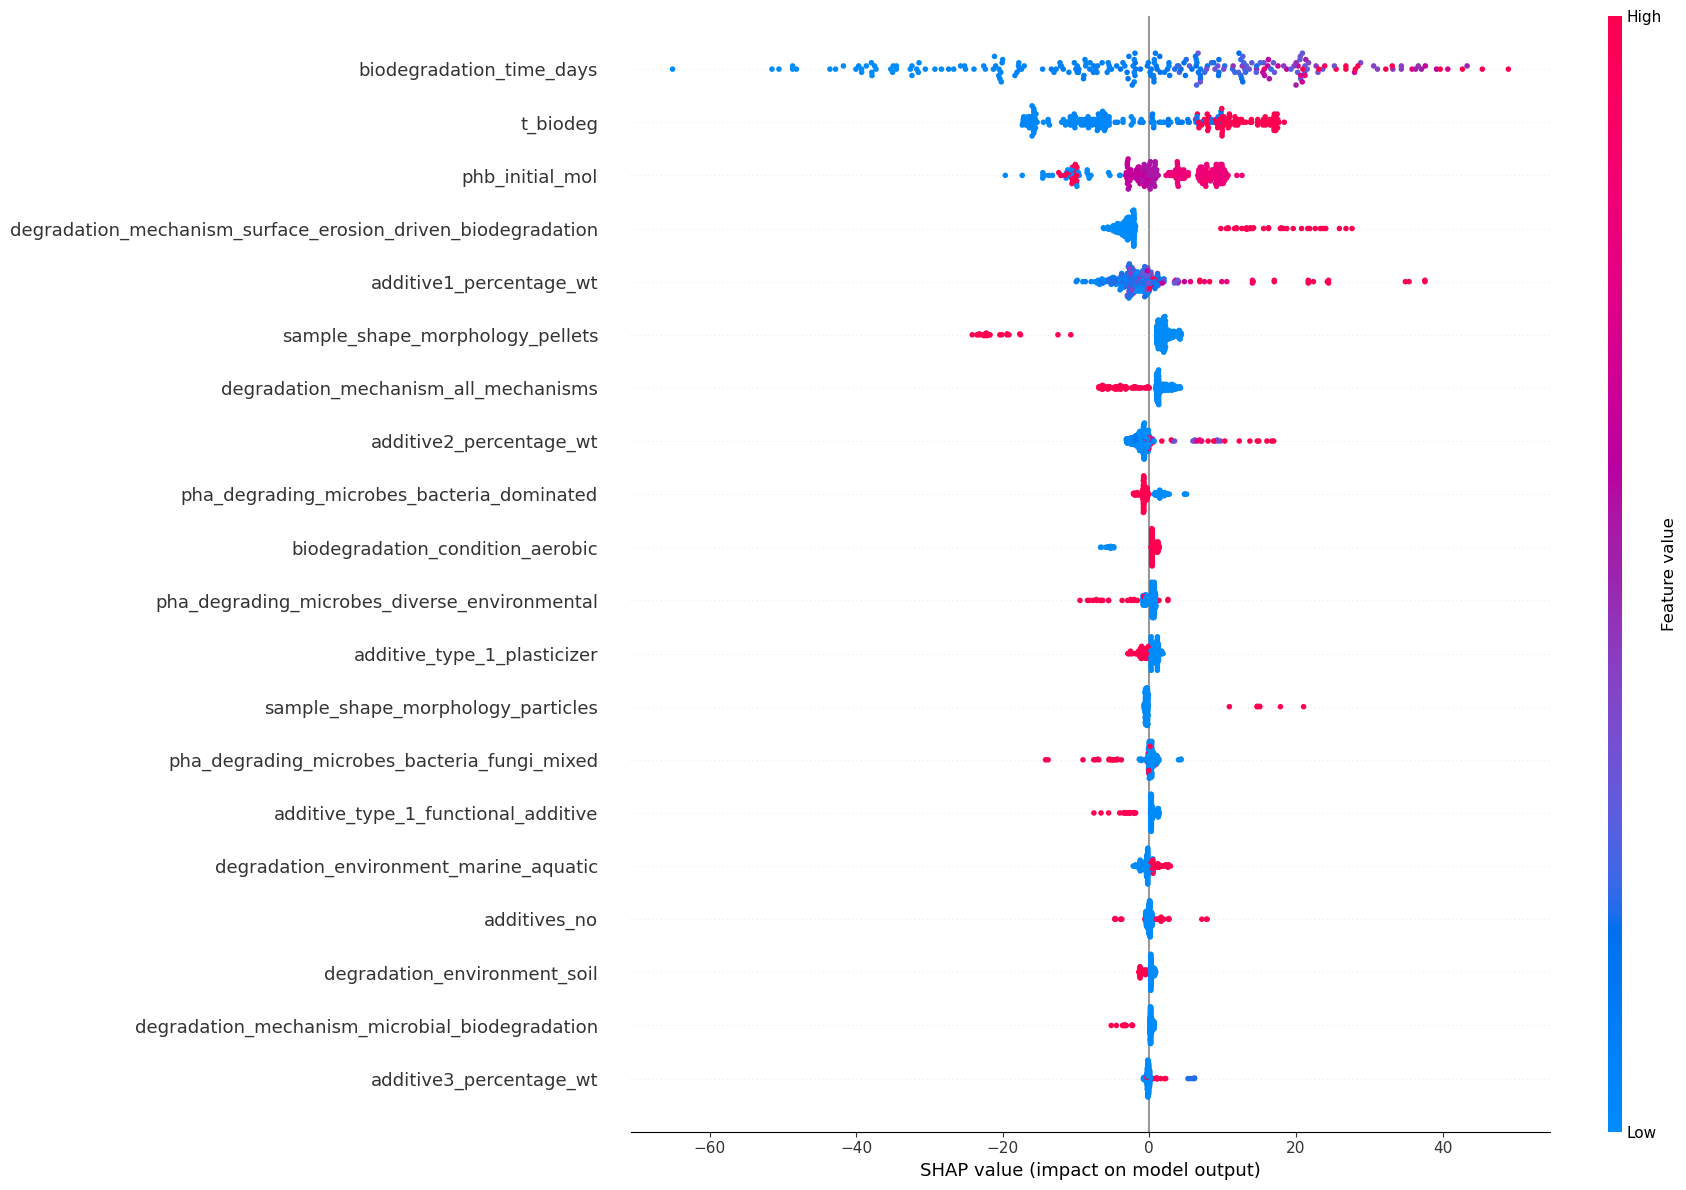

In [123]:
shap.summary_plot(
    shap_values2,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(18, 12)
)

plt.tight_layout()
plt.savefig("XGB_shap2.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

## SHAP force plot

In [ ]:
def abbreviate(col):
    return (
        col.replace("degradation_", "deg_")
           .replace("adjusted_", "adj_")
           .replace("_formulation_mol", "")
           .replace("environment_", "env_")
           .replace("_days", "")
           .replace("percentage_", "pct_")
           .replace("experimental_", "exp_")
           .replace("additive", "add")
           .replace("degrading_", "deg_")
           .replace("dominated", "dom")
           .replace("microbes_", "micro_")
           .replace("bacteria_", "bact_")
           .replace("plasticizer", "plastic")
    )

X_test_short = X_test_final.copy()
X_test_short.columns = [abbreviate(c) for c in X_test_short.columns]

In [ ]:
i=4

plt.figure(figsize=(12, 12)) 

shap.force_plot(
    base_value,
    shap_values[i, :],
    X_test_short.iloc[i, :],
    matplotlib=True,
    show = False
#    contribution_threshold=0.05  # hides tiny contributions
)

plt.tight_layout()
plt.show()

## Validation check on unseen data (excl. full instances)

In [91]:
# transform validation set
X_val = df_val.drop(columns=[target,'study_id','instance'])
X_val_ohe = ohe.transform(X_val[categorical_cols_lst])
X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
X_val_final = pd.concat([X_val.drop(columns=categorical_cols_lst), X_val_ohe_df], axis=1)
X_val_final = X_val_final[selected_features]

In [94]:
cols = X_val_final.columns.tolist()
first_col = cols.pop(0)

# Insert it at index 2 (third position)
cols.insert(2, first_col)
# X_val_final = X_val_final[cols]
y_val = df_val[target]

# RF
y_val_pred_rf = best_rf.predict(X_val_final)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
print(f'R^2 score on unseen set (RF): {r2_val_rf}')

# XGBoost
y_val_pred_xg = xgb.predict(X_val_final)
r2_val_xg = r2_score(y_val, y_val_pred_xg)
print(f'R^2 score on unseen set (xgb): {r2_val_xg}')

R^2 score on unseen set (RF): 0.9623992764071485
R^2 score on unseen set (xgb): 0.8339612443429397


## Results table - RF

In [97]:
# RF
df_eval_rf = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_rf
})

df_eval_rf['error'] = np.abs(df_eval_rf['y_test'] - df_eval_rf['y_pred'])

best_rows = df_eval_rf.loc[df_eval_rf.groupby('study_id')['error'].idxmin()]
best_rows_sorted = best_rows.sort_values(by='error', ascending=True)
best_rows_sorted

,pos,study_id,instance,y_test,y_pred,error
1161,97,22,3,60.0,60.004786,0.004786
599,2,6,4,2.0,1.994778,0.005222
1285,131,24,1,68.0,68.112060,0.112060
869,40,16,1,10.0,9.861671,0.138329
1079,76,20,3,20.0,19.836552,0.163448
1265,111,23,4,18.0,18.667333,0.667333


## Plot results - RF

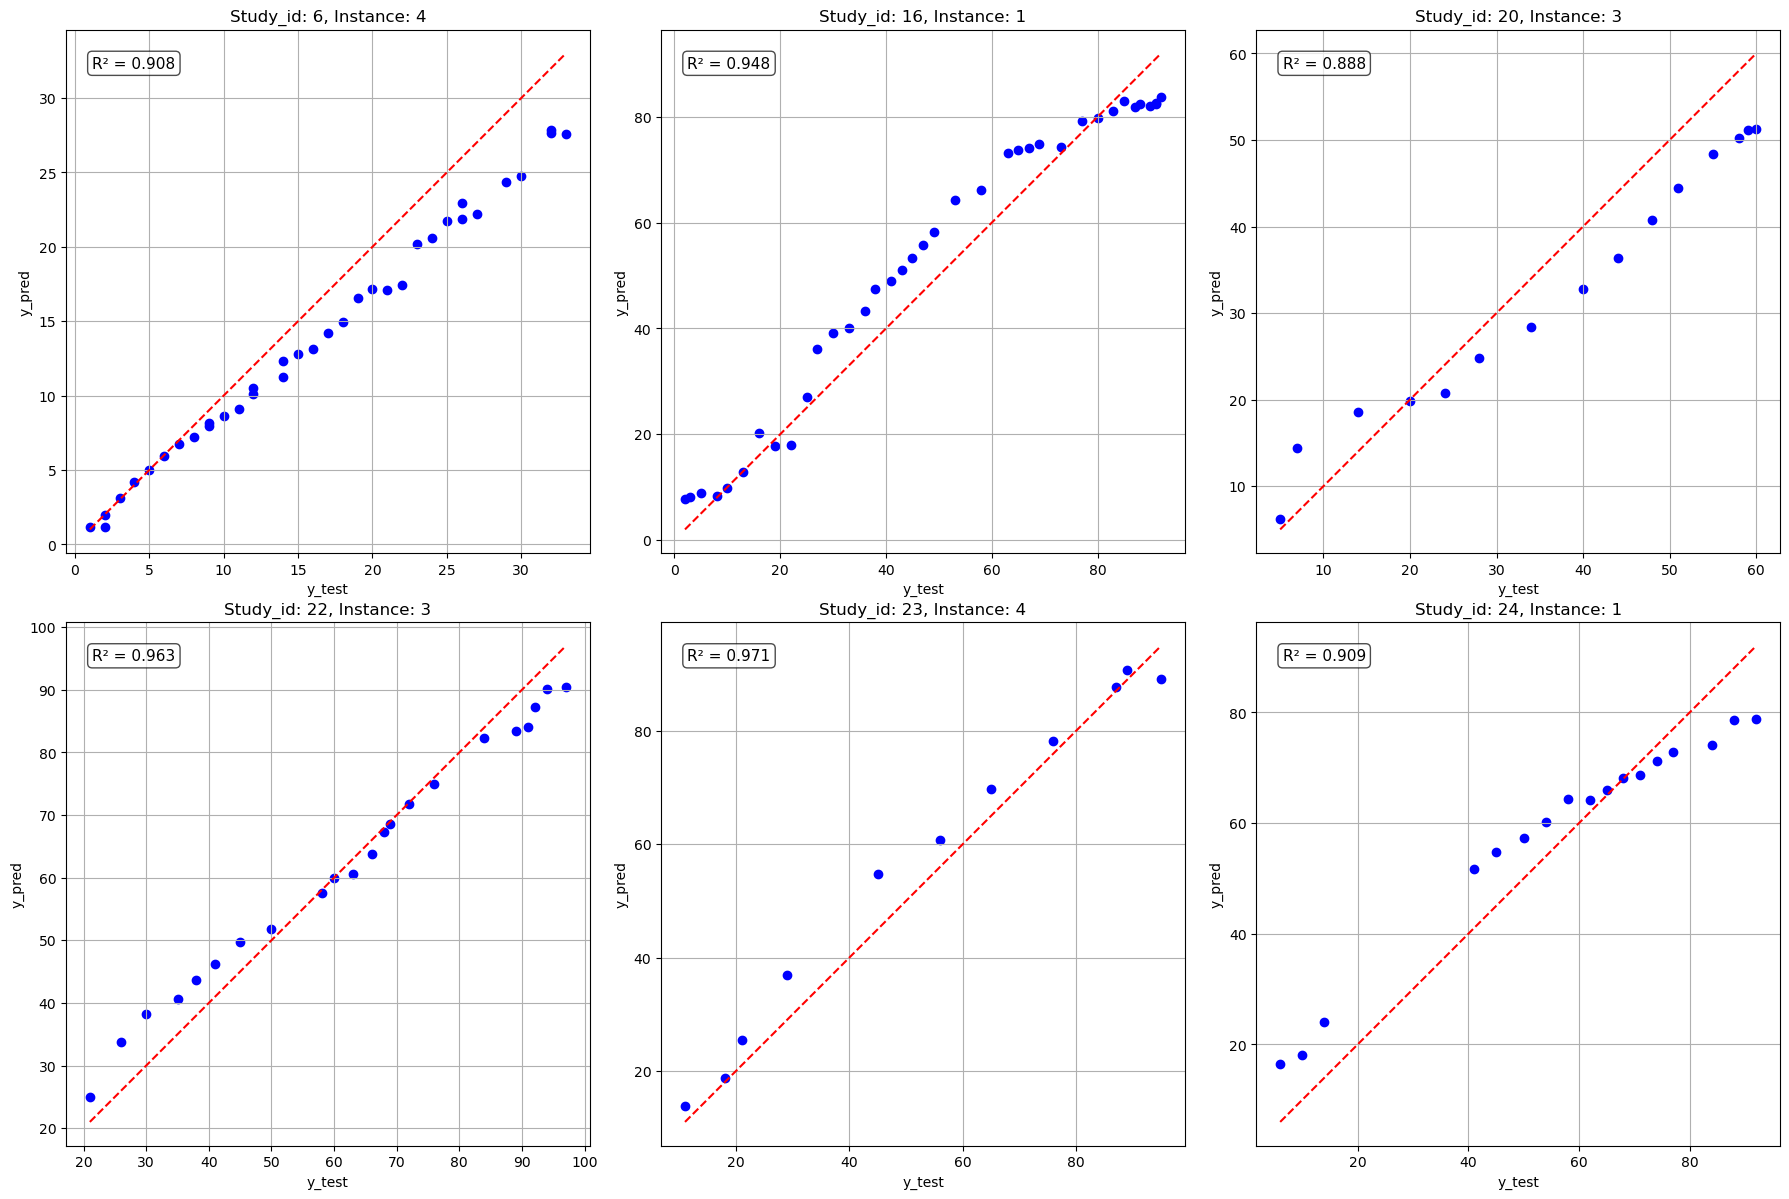

In [98]:
study_ids = df_eval_rf['study_id'].unique().tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_rf[df_eval_rf['study_id'] == study_id]

    r2 = r2_score(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [95]:
# XGBoost
df_eval_xg = pd.DataFrame({
    'pos': np.arange(len(y_val)),
    'study_id': df_val['study_id'].values,
    'instance': df_val['instance'].values,
    'y_test': y_val,
    'y_pred': y_val_pred_xg
})

df_eval_xg['error'] = np.abs(df_eval_xg['y_test'] - df_eval_xg['y_pred'])

best_rows2 = df_eval_xg.loc[df_eval_xg.groupby('study_id')['error'].idxmin()]
best_rows_sorted2 = best_rows2.sort_values(by='error', ascending=True)
best_rows_sorted2

,pos,study_id,instance,y_test,y_pred,error
1155,91,22,3,35.0,35.337147,0.337147
1081,78,20,3,28.0,28.426470,0.426470
599,2,6,4,2.0,1.477911,0.522089
1291,137,24,1,92.0,92.793709,0.793709
1271,117,23,4,76.0,77.088432,1.088432
901,72,16,1,92.0,93.836334,1.836334


## Plot results - XGBoost

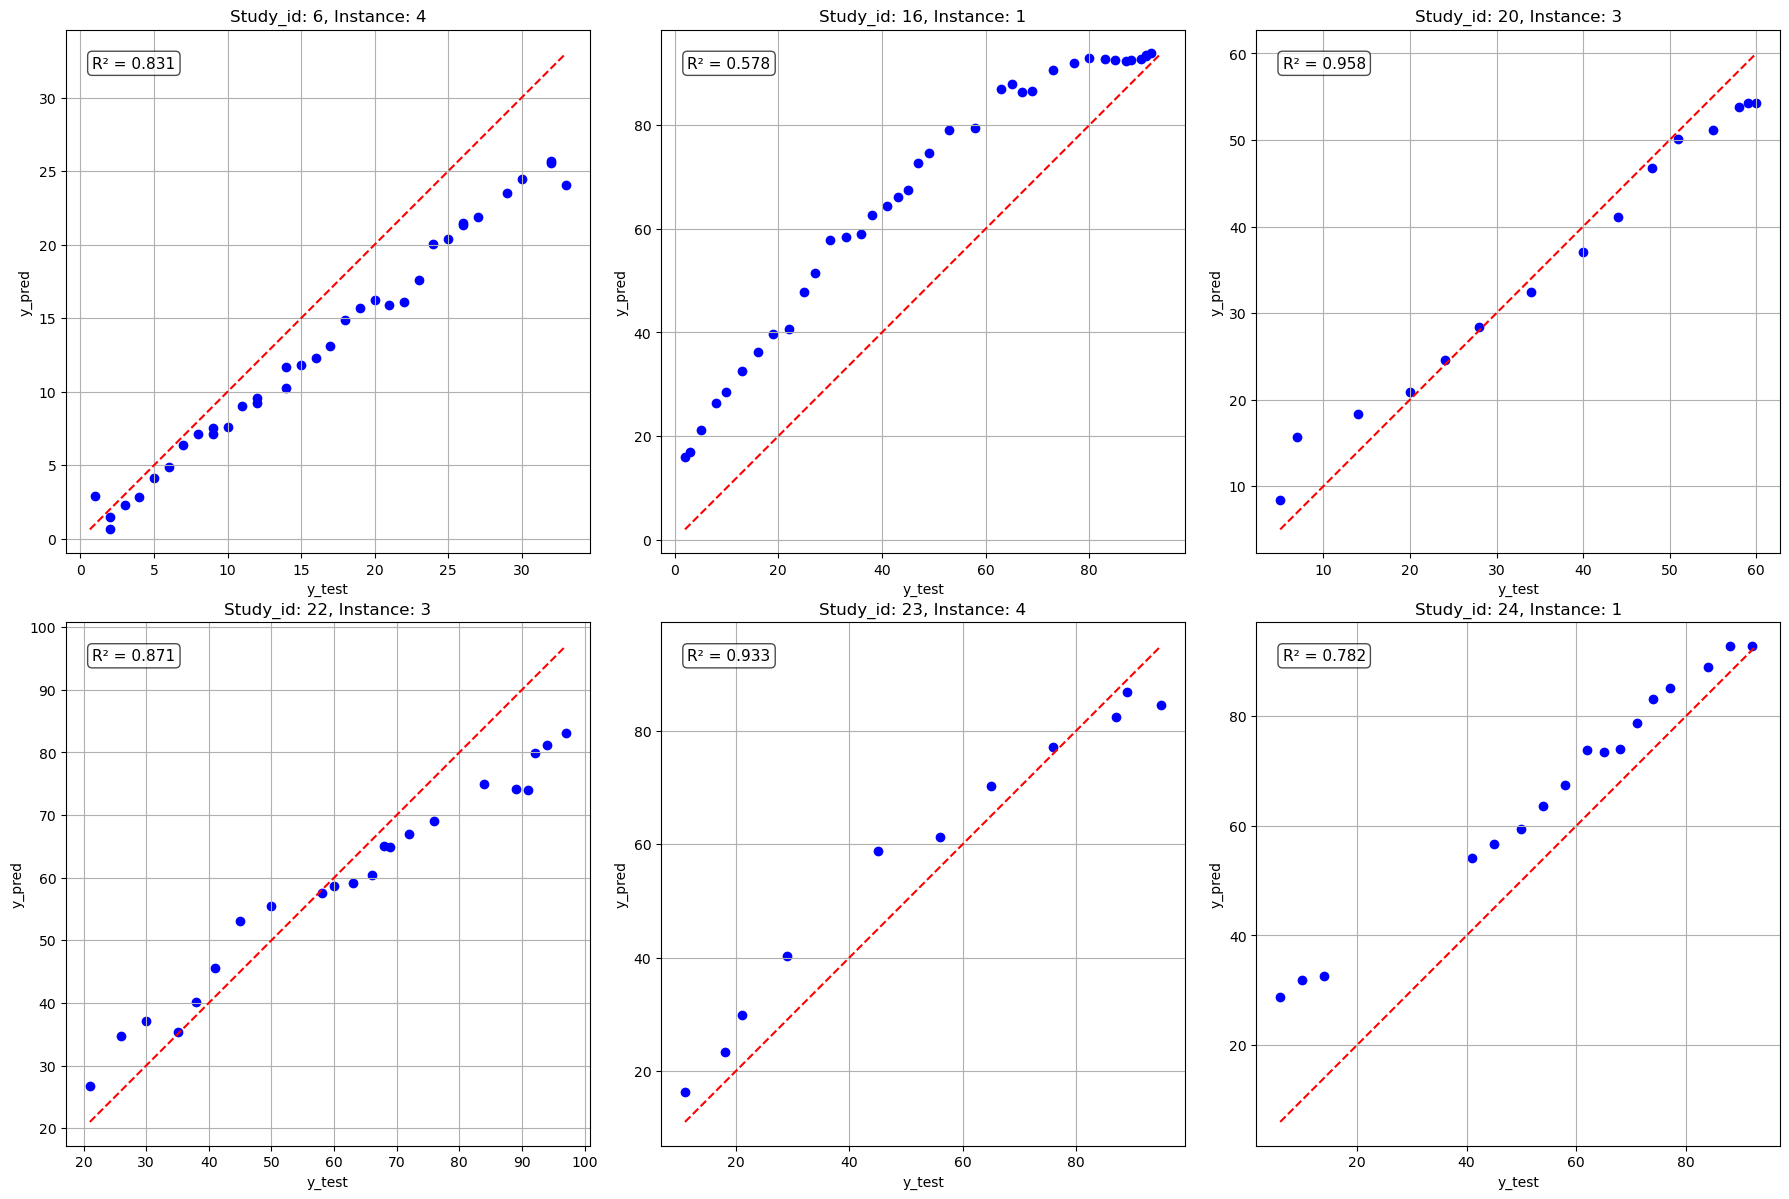

In [96]:
study_ids = df_eval_xg['study_id'].unique().tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear() 

    subset = df_eval_xg[df_eval_xg['study_id'] == study_id]

    r2 = r2_score(subset['y_test'], subset['y_pred'])

    ax.scatter(subset['y_test'], subset['y_pred'], color='blue')

    min_val = min(subset['y_test'].min(), subset['y_pred'].min())
    max_val = max(subset['y_test'].max(), subset['y_pred'].max())

    instance = subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(f'Study_id: {study_id}, Instance: {instance}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

## Plot best model on unseen data

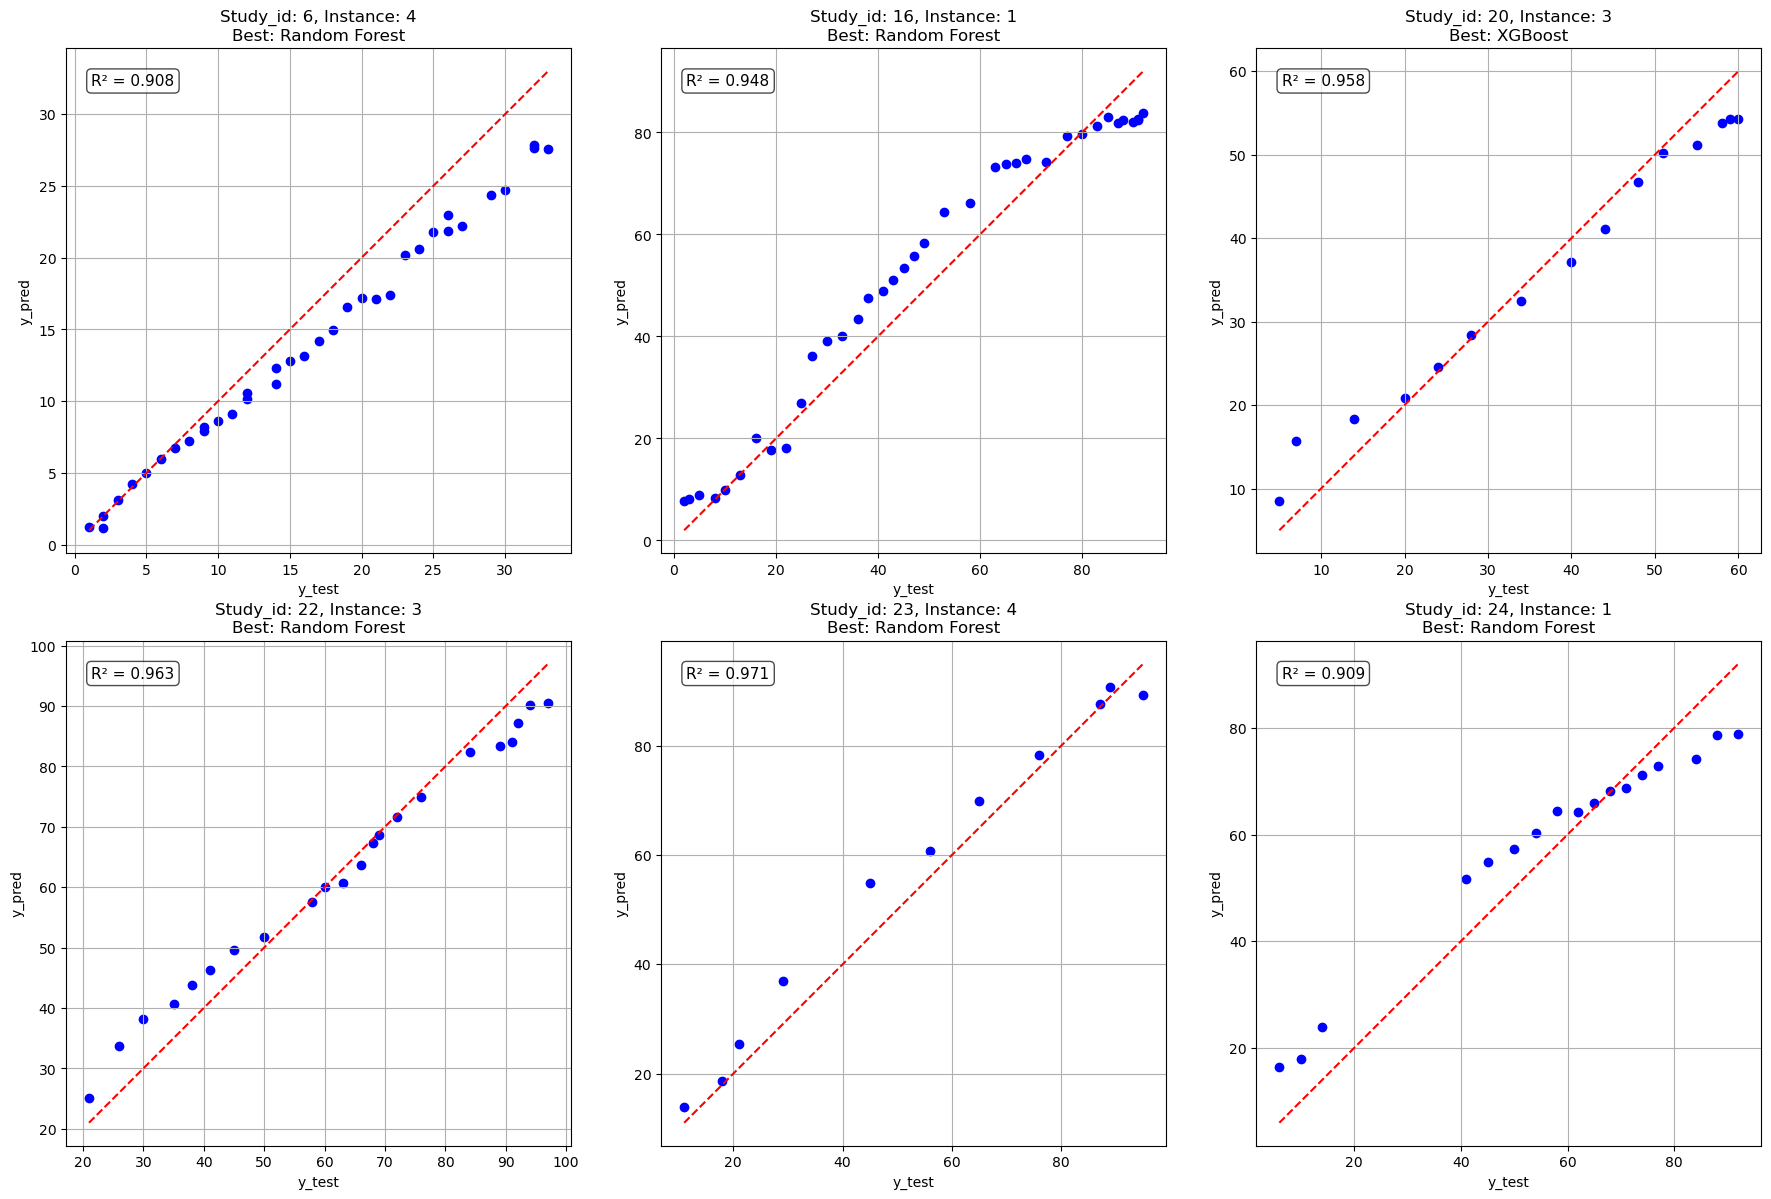

In [99]:
# Combine study IDs from both datasets
study_ids = df_val['study_id'].unique()

# Prepare figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, study_id in zip(axes, study_ids):
    ax.clear()

    # Subset for both models
    subset_xg = df_eval_xg[df_eval_xg['study_id'] == study_id]
    subset_rf = df_eval_rf[df_eval_rf['study_id'] == study_id]

    # Compute R² for both models
    r2_xg = r2_score(subset_xg['y_test'], subset_xg['y_pred']) if not subset_xg.empty else float('-inf')
    r2_rf = r2_score(subset_rf['y_test'], subset_rf['y_pred']) if not subset_rf.empty else float('-inf')

    # Choose the best model
    if r2_xg >= r2_rf:
        best_subset = subset_xg
        best_model = 'XGBoost'
        best_r2 = r2_xg
    else:
        best_subset = subset_rf
        best_model = 'Random Forest'
        best_r2 = r2_rf

    # Plot
    ax.scatter(best_subset['y_test'], best_subset['y_pred'], color='blue')

    min_val = min(best_subset['y_test'].min(), best_subset['y_pred'].min())
    max_val = max(best_subset['y_test'].max(), best_subset['y_pred'].max())

    instance = best_subset['instance'].iloc[0]

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_title(f'Study_id: {study_id}, Instance: {instance}\nBest: {best_model}')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    ax.text(
        0.05, 0.95,
        f'R² = {best_r2:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.tight_layout()  # prevent overlap
plt.savefig('unseen_excl2.tiff', format='tiff', dpi=300)
plt.show()

## Williams plot

In [ ]:
from sklearn.linear_model import LinearRegression

# -----------------------------
# Training data
# -----------------------------
X_train = X_train_final.values if hasattr(X_train_final, "values") else X_train_final
y_train = y_train_clean.values if hasattr(y_train_clean, "values") else y_train_clean

# Test data
X_test2 = X_test_final.values if hasattr(X_test_final, "values") else X_test_final
y_test = y_test.values if hasattr(y_test, "values") else y_test

# -----------------------------
# Linear regression for diagnostics
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test2)

# -----------------------------
# Standardized residuals (δ)
# -----------------------------
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

res_std = np.std(train_residuals)
train_delta = train_residuals / res_std
test_delta = test_residuals / res_std

# -----------------------------
# Leverage calculation
# (Hat matrix from training data)
# -----------------------------
X_train_i = np.column_stack([np.ones(X_train.shape[0]), X_train])
H = X_train_i @ np.linalg.pinv(X_train_i.T @ X_train_i) @ X_train_i.T
train_leverage = np.diag(H)

# Leverage for test set
X_test_i = np.column_stack([np.ones(X_test2.shape[0]), X_test2])
test_leverage = np.sum(
    X_test_i @ np.linalg.pinv(X_train_i.T @ X_train_i) * X_test_i,
    axis=1
)

# -----------------------------
# Warning leverage threshold
# -----------------------------
n = X_train_i.shape[0]
p = X_train_i.shape[1]
h_star = 3 * p / n

# -----------------------------
# Williams plot
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    train_leverage, train_delta,
    color="blue", alpha=0.6, label="Training set"
)
plt.scatter(
    test_leverage, test_delta,
    color="red", alpha=0.8, label="Test set"
)

plt.axhline(3, linestyle="--", linewidth=1)
plt.axhline(-3, linestyle="--", linewidth=1)
plt.axvline(h_star, linestyle="--", linewidth=1)

plt.xlabel("Leverage (h)")
plt.ylabel("Standardized Residuals (δ)")
plt.title("Williams Plot for Training and Test Sets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Warning leverage threshold (h*): {h_star:.4f}")

## Jaqpot

In [106]:
df_final.columns

Index(['phb_initial_mol', 'biodegradation_time_days',
       'biodegradation_condition', 'degradation_mechanism', 't_biodeg',
       'degradation_environment', 'additive_type_1', 'additive1_percentage_wt',
       'additive_type_2', 'additive2_percentage_wt', 'additive_type_3',
       'additive3_percentage_wt', 'pha_degrading_microbes',
       'sample_shape_morphology', 'additives', 'biodegradation_percentage'],
      dtype='object')

In [107]:
numerical_cols_lst = (
    df_final
    .select_dtypes(include=[np.number])
    .columns
    .difference(['additive3_percentage_wt'])
    .tolist()
)

categorical_cols_lst = (
    df_final
    .select_dtypes(include=['object', 'category'])
    .columns
    .difference(['additive_type_3','additives'])
    .tolist()
)

exclude_cols = [
    'additive_type_3',
    'additive3_percentage_wt',
    'additives'
]

In [108]:
numerical_cols_lst.remove(target)
features_num = numerical_cols_lst
features_cat = categorical_cols_lst

In [109]:
X_train_clean = X_train_clean.drop(columns=exclude_cols, errors='ignore')
df_train = X_train_clean.copy()
df_train[target] = y_train_clean

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train_clean.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [110]:
X_test = X_test.drop(columns=exclude_cols, errors='ignore')
df_test = X_test.copy()
df_test[target] = y_test

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test.columns.to_list(),
    y_cols=target,
    task="REGRESSION",
)

In [111]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat)
    ],
    remainder='drop',
)

In [112]:
model = RandomForestRegressor(random_state=42, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300)
jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=preprocessing,
  )

jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'r2': 0.9815261343044638, 'mae': 2.010824308929921, 'rmse': 4.543458424356918}


In [113]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=10)

{'r2': 0.9473996091998023, 'mae': 4.220484729707179, 'rmse': 7.417029502583793}

In [114]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'r2': 0.958924719042606, 'mae': 4.018972399664473, 'rmse': 6.6479045951531095}

In [115]:
# Conducts a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'r2': 0.7311221101418739,
   'mae': 14.048152982693798,
   'rmse': 17.333458016861453},
  'Test': {'r2': -0.15806687289040022,
   'mae': 29.92495009131188,
   'rmse': 35.298912534439914}},
 'iteration_1': {'Train': {'r2': 0.7456006704096563,
   'mae': 13.452502472121605,
   'rmse': 16.860313614944463},
  'Test': {'r2': -0.292604543511118,
   'mae': 31.70195130016776,
   'rmse': 37.2930021249295}},
 'iteration_2': {'Train': {'r2': 0.7573412737318979,
   'mae': 13.297591887534233,
   'rmse': 16.466664010291428},
  'Test': {'r2': -0.34699761986583133,
   'mae': 32.30661479975911,
   'rmse': 38.06956558009845}},
 'iteration_3': {'Train': {'r2': 0.7369355061665008,
   'mae': 13.992441464818251,
   'rmse': 17.145051133593206},
  'Test': {'r2': -0.25511906893445047,
   'mae': 31.040203682195553,
   'rmse': 36.748276106515775}},
 'iteration_4': {'Train': {'r2': 0.7218336717379676,
   'mae': 14.470659024894228,
   'rmse': 17.630309902019683},
  'Test': {'r2': -0.32049

In [116]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)
print(doa_predictions)

{'LEVERAGE': [{'h': 0.08445004754601741, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.014675378499567352, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.030038266654506266, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.050411652813067115, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.01814926873668146, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.047904517631704696, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.025755812015859084, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.014271618357079189, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.023915109312561626, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.019657123678359114, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.014963963790710957, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.04814332691895884, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.014258682529787126, 'hStar': 0.10714285714285714, 'inDoa': True}, {'h': 0.01537260659096443, 

In [117]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 246, 'n_in': 246, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 246, 'n_in': 246, 'n_out': 0}}

## Upload model

In [118]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Biodegradation percentage regression model A.N.I.P.H.",
    description="Prediction of biodegradation percentage of PHBV polymers.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-06-19 14:34:52,499 - INFO - Large model detected, using /v1/large-models flow
  2026-06-19 14:34:56,374 - INFO - Uploading your model directly to s3, due to its large size...
Uploading: 100%|█████████▉| 11.9M/11.9M [00:08<00:00, 1.27MB/s]

✅ File uploaded successfully.


Uploading: 100%|██████████| 11.9M/11.9M [00:09<00:00, 1.20MB/s]
  2026-06-19 14:35:06,442 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2371


## DOA

In [120]:
df_train[features_num].agg(['min', 'max'])

,additive1_percentage_wt,additive2_percentage_wt,biodegradation_time_days,phb_initial_mol,t_biodeg
min,0.0,0.0,1.0,88,23.0
max,70.0,70.0,452.0,99,58.0


In [122]:
df_train.head()

,phb_initial_mol,biodegradation_time_days,biodegradation_condition,degradation_mechanism,t_biodeg,degradation_environment,additive_type_1,additive1_percentage_wt,additive_type_2,additive2_percentage_wt,pha_degrading_microbes,sample_shape_morphology,biodegradation_percentage
306,95,168.0,aerobic,enzyme_mediated_microbial_biodegradation,25.0,marine_aquatic,plasticizer,10.0,filler,4.5,bacteria_dominated,pellets,9.0
1207,95,141.0,aerobic,hydrolysis_assisted_microbial_assimilation,25.0,marine_aquatic,no_additive,0.0,filler,25.0,bacteria_dominated,matrix_composites,70.0
10,88,55.0,aerobic,hydrolysis_assisted_microbial_assimilation,58.0,compost_organic_fertilizer,plasticizer,10.0,no_additive,0.0,bacteria_dominated,films,28.0
535,99,332.0,anaerobic,all_mechanisms,25.0,soil,filler,20.0,no_additive,0.0,bacteria_dominated,sheets,33.0
428,94,14.0,aerobic,enzyme_mediated_microbial_biodegradation,25.0,marine_aquatic,filler,50.0,no_additive,0.0,bacteria_dominated,films,51.0
